In [44]:
import json
import math
from matplotlib import gridspec
from collections import Counter
from augur.utils import json_to_tree
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Find number of adaptive sites at percentage various thresholds 

In [22]:
def get_muts_over_threshold(virus, segment, gene, threshold):
    """
    Return all muts over the threshold
    """
    
    muts_file = f"../egg-mutation-analysis/egg-mut-counts/{virus}_{segment.upper()}_{gene.upper()}_egg-mut-counts.json"
    
    with open(muts_file) as json_handle:
        egg_mut_info = json.load(json_handle)
    
    
    sites_above_threshold = [x for s,x in egg_mut_info['mutated_sites_freqs'].items() if x>=threshold]
    num_sites_above_threshold = len(sites_above_threshold)    
    
    total_num_egg_strains = egg_mut_info['total_num_egg_strains']
    
    return num_sites_above_threshold
        

In [23]:
cmap = {'h3n2': '#6C3BAA', 'h1n1pdm': '#45b6fe', 'vic': '#FF4500', 'yam': '#fbba0a'}

In [36]:
def plot_histogram():
    
    viruses = ['h3n2', 'h1n1pdm', 'vic', 'yam']
    
    thresholds = [0.001, 0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05, 0.055, 0.06, 0.065, 0.07, 0.075, 0.08, 0.085, 0.09, 0.095, 0.1]
    
    to_plot = []
    for v in viruses:
        for t in thresholds:
            num_sites_above_threshold = get_muts_over_threshold(v, 'ha', 'HA1', t)
            to_plot.append({'virus': v, 'threshold': t, 'num_sites_above_threshold': num_sites_above_threshold})
    df = pd.DataFrame(to_plot)
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize=(10,6), sharex=True)
    
    sns.barplot(x='threshold', y='num_sites_above_threshold', color=cmap['h3n2'], data = df[df['virus']=='h3n2'], ax=ax1)
    sns.barplot(x='threshold', y='num_sites_above_threshold', color=cmap['h1n1pdm'], data = df[df['virus']=='h1n1pdm'], ax=ax2)
    sns.barplot(x='threshold', y='num_sites_above_threshold', color=cmap['vic'], data = df[df['virus']=='vic'], ax=ax3)
    sns.barplot(x='threshold', y='num_sites_above_threshold', color=cmap['yam'], data = df[df['virus']=='yam'], ax=ax4)

    for ax in [ax1, ax2, ax3, ax4]:
        xticks = ax.get_xticks()
        xticklabels = [label.get_text() for label in ax.get_xticklabels()]

        # Set new labels: keep every other, set others to empty string
        new_labels = [label if i % 2 == 0 else '' for i, label in enumerate(xticklabels)]

        ax.set_xticklabels(new_labels, rotation=90)
        ax.set_xlabel('')
        ax.set_ylabel('')
        
    for ax in [ax1, ax3]:
        ax.set_ylabel("Num 'adaptive' sites")
    for ax in [ax3, ax4]:
        ax.set_xlabel('Threshold')

    
    sns.despine()
    

In [88]:
def test():
    viruses = ['h3n2', 'h1n1pdm', 'vic', 'yam']
    
    thresholds = [0.001, 0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05, 
                  0.055, 0.06, 0.065, 0.07, 0.075, 0.08, 0.085, 0.09, 0.095, 0.1, 0.105, 
                  0.11, 0.115, 0.12, 0.125, 0.13, 0.135, 0.14, 0.145, 0.15]
    
    to_plot = []
    for v in viruses:
        for t in thresholds:
            num_sites_above_threshold = get_muts_over_threshold(v, 'ha', 'HA1', t)
            to_plot.append({'virus': v, 'threshold': t, 'num_sites_above_threshold': num_sites_above_threshold})
    df = pd.DataFrame(to_plot)
    
    
    # Set up the figure
    
    fig = plt.figure(figsize=(12, 8))
    gs = gridspec.GridSpec(5, 2, height_ratios=[1, 3, 0.3, 1, 3], hspace=0.3)

    axs_top = []
    axs_bottom = []

    for i, virus in enumerate(viruses):
        col = i % 2
        row = (i // 2) * 3  

        ax_top = fig.add_subplot(gs[row, col])
        ax_bottom = fig.add_subplot(gs[row + 1, col], sharex=ax_top)

        axs_top.append(ax_top)
        axs_bottom.append(ax_bottom)

        data = df[df['virus'] == virus]

        sns.barplot(x='threshold', y='num_sites_above_threshold', color=cmap[virus], data=data, ax=ax_top)
        sns.barplot(x='threshold', y='num_sites_above_threshold', color=cmap[virus], data=data, ax=ax_bottom)
        
        # Set y limits
        ax_top.set_ylim(20, data['num_sites_above_threshold'].max() + 5)
        ax_bottom.set_ylim(0, 20)
        
        # Hide the spines between top and bottom
        ax_top.spines['bottom'].set_visible(False)
        ax_bottom.spines['top'].set_visible(False)
        ax_top.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
        ax_bottom.xaxis.tick_bottom()

        # Add diagonal break marks
        d = .5  # size of diagonal lines
        kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12, linestyle='none', color='k', mec='k', mew=1, clip_on=False)
        ax_top.plot([0, 0], [0, 0], transform=ax_top.transAxes, **kwargs)
        ax_bottom.plot([0, 0], [1, 1], transform=ax_bottom.transAxes, **kwargs)

        # X-axis labels every other
        xticks = ax_bottom.get_xticks()
        xticklabels = [label.get_text() for label in ax_bottom.get_xticklabels()]
        new_labels = [label if idx % 2 == 0 else '' for idx, label in enumerate(xticklabels)]
        ax_bottom.set_xticklabels(new_labels, rotation=90)
        
        # label viruses
        virus_legible = {'h3n2': 'H3N2', 'h1n1pdm': 'H1N1pdm', 'vic': 'Vic', 'yam': 'Yam'}
        ax_top.text(
            0.92, 0.95, virus_legible[virus], 
            transform=ax_top.transAxes,
            ha='right', va='top',
            fontsize=16,
        )

        # Label axes
        if col == 0:
            ax_bottom.set_ylabel("Num 'adaptive' sites")
            ax_top.set_ylabel("")
        else:
            ax_bottom.set_ylabel("")
            ax_top.set_ylabel("")
        if row == 3:
            ax_bottom.set_xlabel('Threshold')
            ax_top.set_xlabel('')
        else:
            ax_bottom.set_xlabel('')
            ax_top.set_xlabel('')
            

            
    sns.despine(bottom = True)


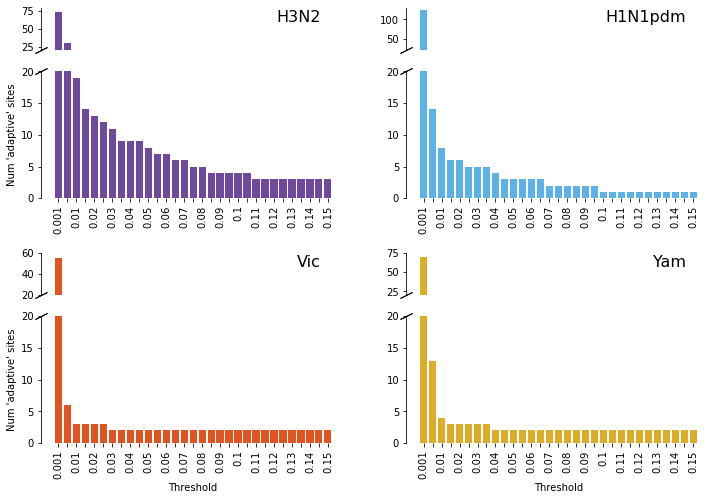

In [89]:
test()

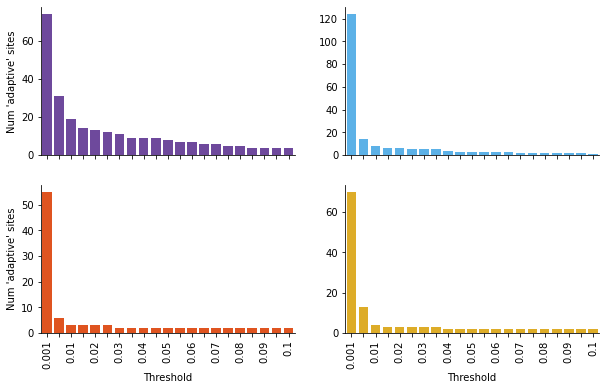

In [37]:
plot_histogram()